In [96]:
import os
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Helper Functions

In [101]:
def get_audio_file_features_data(filepath, model_name, audio_model_files):
    if model_name not in audio_model_files:
        audio_model_files[model_name] = {}

    feature_type = '_'.join(file.split('_')[1:-1]) # file convention is {model_name}_{dataname...}_{data}
    df = pd.read_csv(filepath)
    df['file_id'] = df['file_id'].str.split('_', n=1).str[1].replace('.wav', '', regex=True)
    audio_model_files[model_name][feature_type] = df
    audio_model_files[model_name]['dataframe'] = None

    return audio_model_files


### Load features extracted from audio files

In [102]:
features_path = '/content/drive/MyDrive/fyp_audio/features'

audio_model_files = {}

for root, dir, files in os.walk(features_path):
    for file in files:
        filepath = os.path.join(root, file)
        modelname = file.split('_')[0]
        audio_model_files = get_audio_file_features_data(filepath, modelname, audio_model_files)

### Load master prompts to get the target values and join with target

In [103]:
master_prompts = '/content/master_prompts_v2.csv'
target_df = pd.read_csv(master_prompts)
target_df = target_df.rename(columns={"filename": "file_id"})

for model_name in audio_model_files:
    current_model_df = target_df.copy()
    for feature_type in audio_model_files[model_name]:
        if feature_type not in ['base_path', 'dataframe']:
            feature_df = audio_model_files[model_name][feature_type]
            prefixed_df = feature_df.add_prefix(f"{feature_type}_")
            prefixed_df = prefixed_df.rename(columns={f"{feature_type}_file_id": "file_id"})
            current_model_df = current_model_df.merge(prefixed_df, how='left', on="file_id")

    audio_model_files[model_name]['dataframe'] = current_model_df


# Process tasks

Here we are iterating over the tasks for each model, and extracting the features we need


### Helper functions for processing tasks

In [126]:
# get mirex score for key
def get_mirex_score(target_key, target_mode, deteced_key, detected_mode):
    note_map = {'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3, 'E': 4, 'F': 5,
                'F#': 6, 'Gb': 6, 'G': 7, 'G#': 8, 'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10, 'B': 11}

    t_val, p_val = note_map.get(target_key), note_map.get(deteced_key)
    if t_val is None or p_val is None: return 0.0

    dist = (p_val - t_val) % 12

    if dist == 0 and target_mode == detected_mode: return 1.0 # Same
    if dist == 7 and target_mode == detected_mode: return 0.5 # 5th
    if target_mode == 'major' and detected_mode == 'minor' and dist == 9: return 0.3 # Relative
    if target_mode == 'minor' and detected_mode == 'major' and dist == 3: return 0.3 # Relative
    if dist == 0 and target_mode != detected_mode: return 0.2 # Parallel
    return 0.0

def mirex_key(target_key, target_mode, detected_key, detected_scale):

    score = get_mirex_score(target_key, target_mode, detected_key, detected_scale)
    return score

In [127]:
# the tasks are tempo, key, scale, tempo change, key modulation, time signature
import pandas as pd

for audio_model in audio_model_files:
    audio_model_df = audio_model_files[audio_model]['dataframe']
    processed_tasks = {}

    split_dfs = {task: group.copy() for task, group in audio_model_df.groupby('task')}

    for task, task_df in split_dfs.items():
        # calculates absolute and signed error for BPM
        if task == 'tempo':
            bpm_cols = [c for c in task_df.columns if '_bpm' in c]

            for col in bpm_cols:
                measured = pd.to_numeric(task_df[col], errors='coerce')
                target = pd.to_numeric(task_df['target'], errors='coerce')

                task_df[f'{col}_abs_error'] = (measured - target).abs()
                task_df[f'{col}_signed_error'] = measured - target

                task_df[f'{col}_tempo_bias'] = task_df[f'{col}_signed_error'].apply(
                    lambda x: 'overshoot' if x > 0.5 else ('undershoot' if x < -0.5 else 'perfect')
                )

        # calculates mirex
        if task == 'key':
            split_target = task_df['target'].str.split(' ', n=1, expand=True)
            task_df['tmp_t_key'] = split_target[0]
            task_df['tmp_t_mode'] = split_target[1]

            # 2. Use axis=1 to iterate row by row
            task_df['mirex_score'] = task_df.apply(
                lambda x: mirex_key(
                    x['tmp_t_key'],
                    x['tmp_t_mode'],
                    x['_key'],
                    x['_scale']
                ), axis=1
            )

        processed_tasks[task] = task_df

    audio_model_files[audio_model]['proccessed_tasks'] = processed_tasks


## Scatter Plots for Target vs Actual BPM

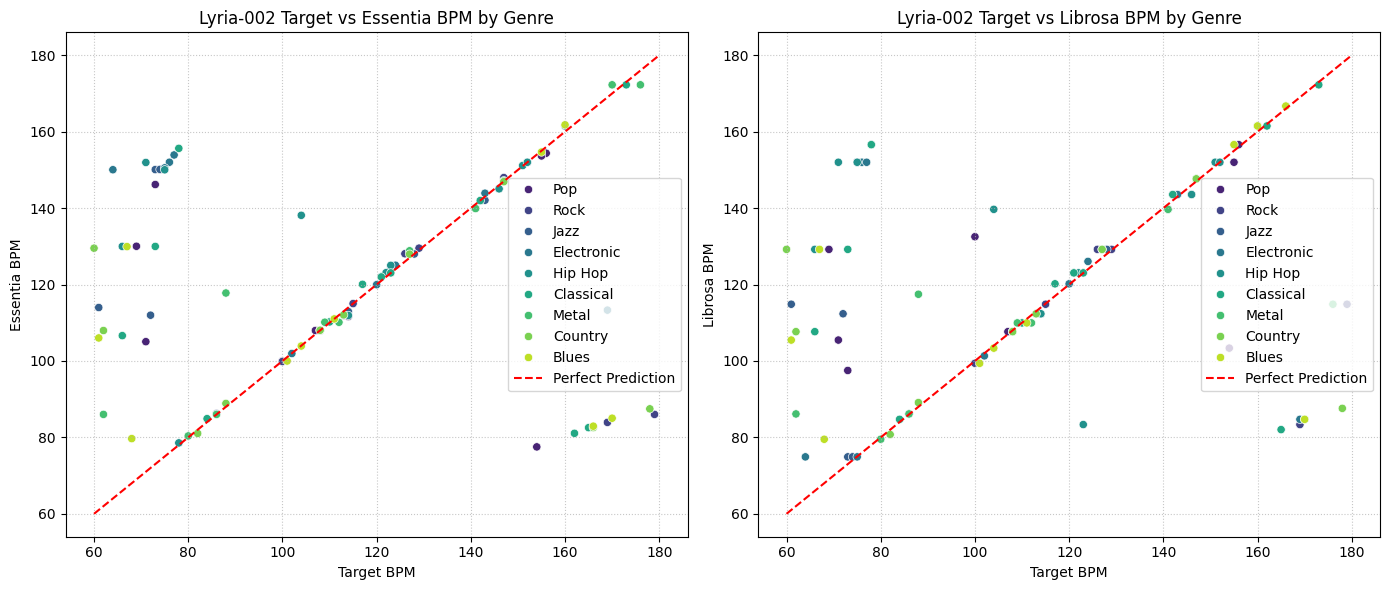

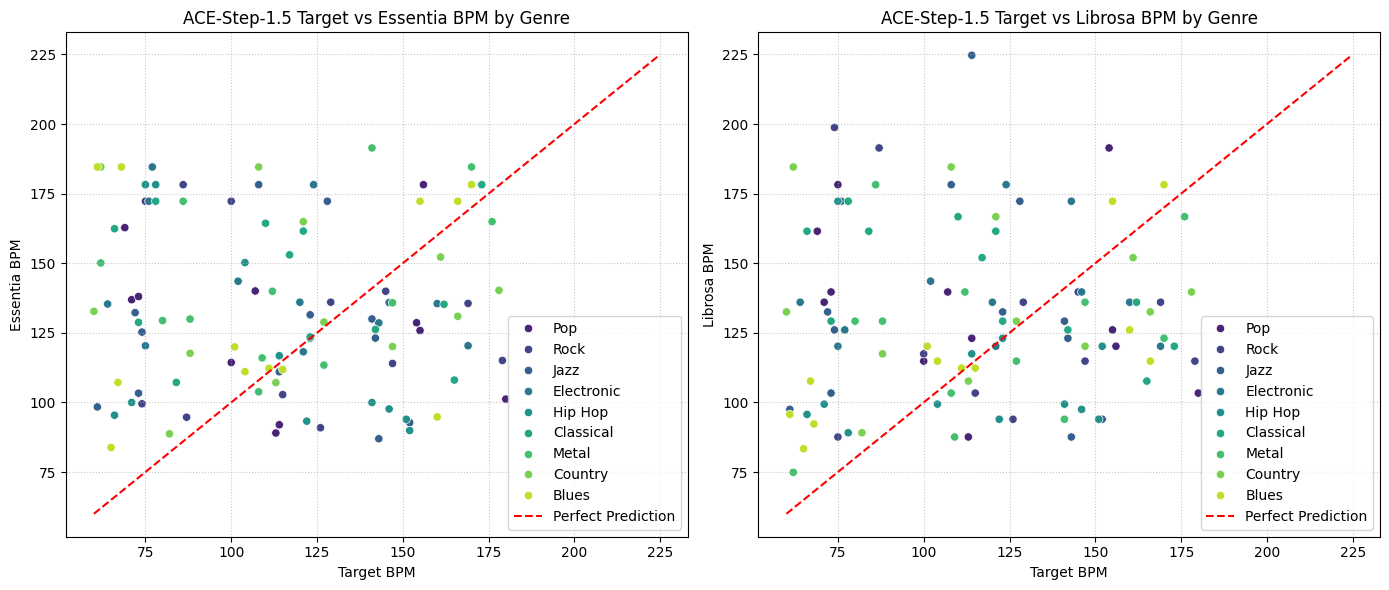

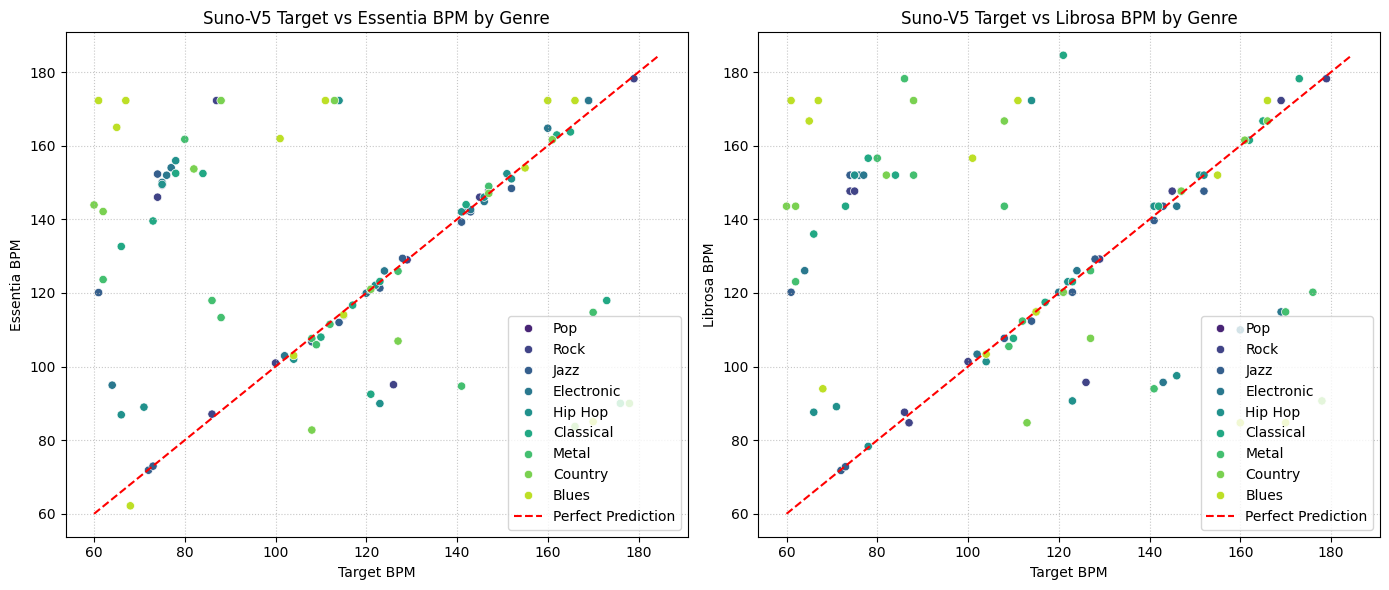

In [128]:
for model_name, model_data in audio_model_files.items():
    tempo_df = model_data['proccessed_tasks']['tempo'].copy()
    tempo_df['target'] = pd.to_numeric(tempo_df['target'], errors='coerce')
    # print(tempo_df['_bpm_essentia'], tempo_df['target'])
    print()
    plt.figure(figsize=(14, 6))

    # Diagonal line
    min_bpm = min(tempo_df['target'].min(), tempo_df['_bpm_essentia'].min(), tempo_df['_bpm_librosa'].min())
    max_bpm = max(tempo_df['target'].max(), tempo_df['_bpm_essentia'].max(), tempo_df['_bpm_librosa'].max())
    diagonal_line = [min_bpm, max_bpm]

    # Essentia BPM plotting
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=tempo_df, x='target', y='_bpm_essentia', hue='genre', palette='viridis')
    plt.plot(diagonal_line, diagonal_line, color='red', linestyle='--', label='Perfect Prediction')
    plt.title(f'{model_name} Target vs Essentia BPM by Genre')
    plt.xlabel('Target BPM')
    plt.ylabel('Essentia BPM')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    # Librosa BPM plotting
    plt.subplot(1, 2, 2)
    sns.scatterplot(data=tempo_df, x='target', y='_bpm_librosa', hue='genre', palette='viridis')
    plt.plot(diagonal_line, diagonal_line, color='red', linestyle='--', label='Perfect Prediction')
    plt.title(f'{model_name} Target vs Librosa BPM by Genre')
    plt.xlabel('Target BPM')
    plt.ylabel('Librosa BPM')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

## Box Plots for Absolute BPM Error by Genre

This shows a box plot for the difference between the target BPM and the measured BPM

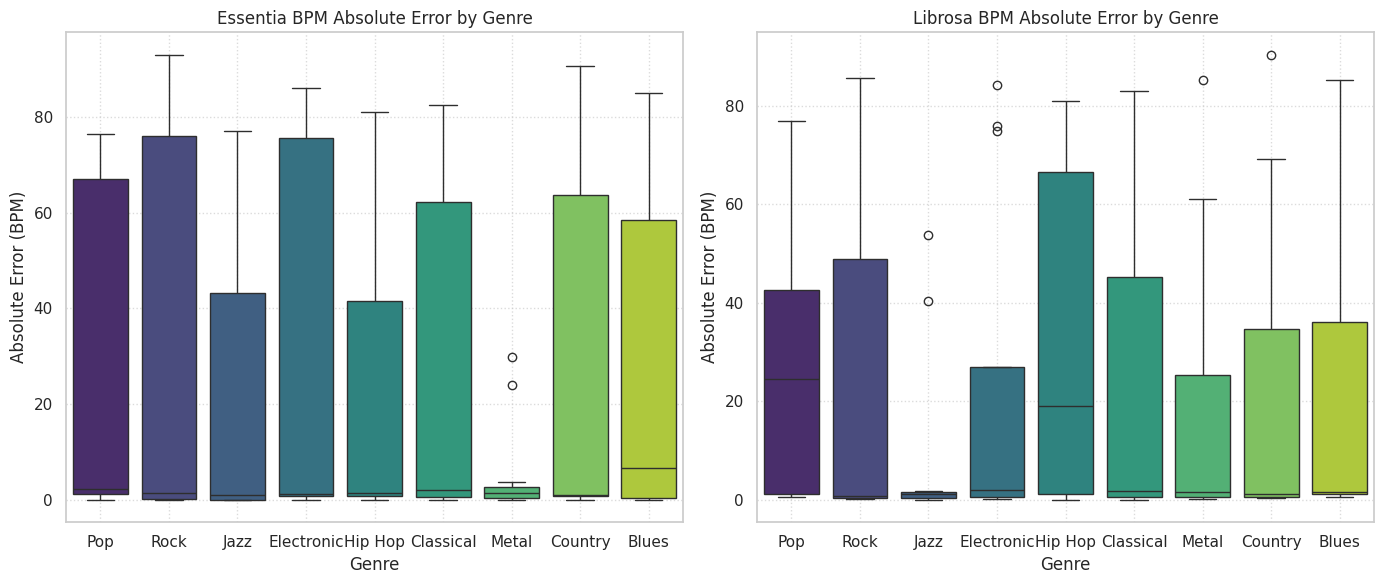

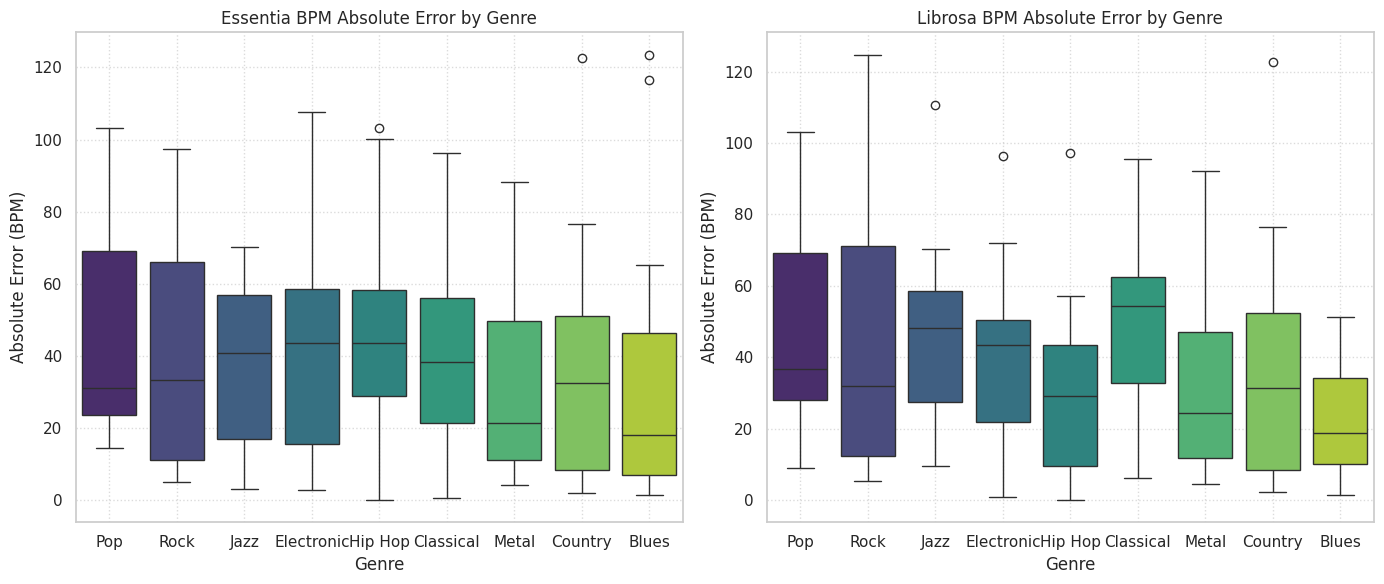

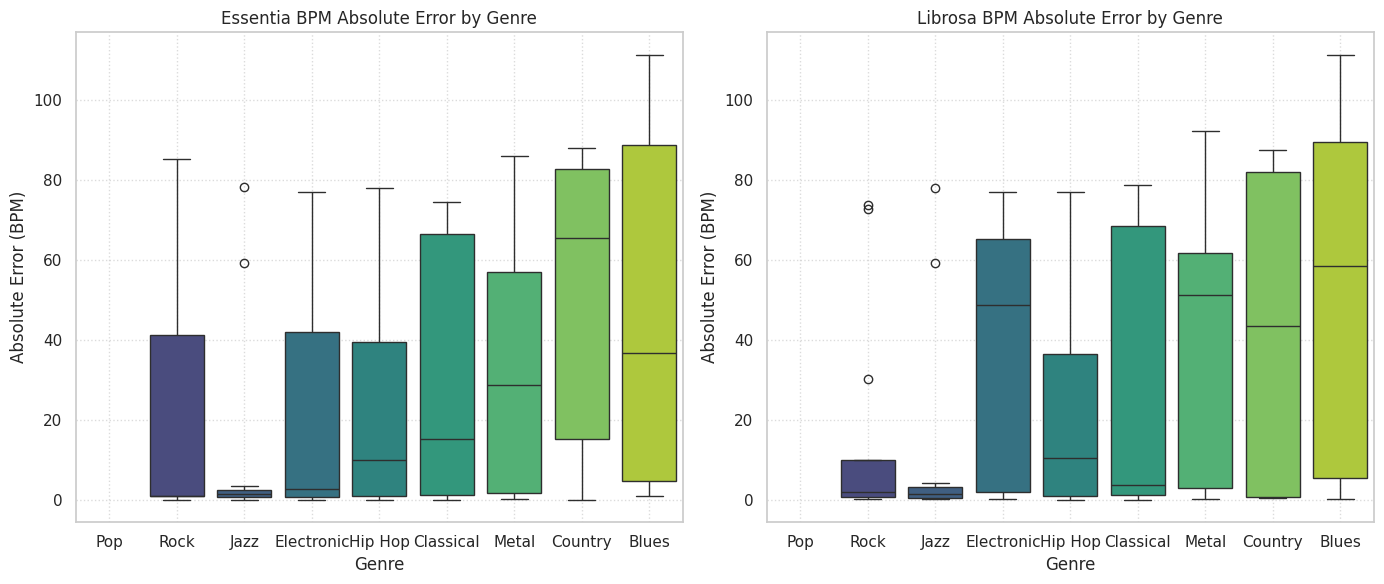

In [136]:
for model_name, model_data in audio_model_files.items():
    tempo_df = model_data['proccessed_tasks']['tempo'].copy()
    tempo_df['target'] = pd.to_numeric(tempo_df['target'], errors='coerce')

    plt.figure(figsize=(14, 6))

    # Box plot for Essentia BPM absolute errors by genre
    plt.subplot(1, 2, 1)
    sns.boxplot(data=tempo_df, x='genre', y='_bpm_essentia_abs_error', hue='genre', palette='viridis', legend=False)
    plt.title('Essentia BPM Absolute Error by Genre')
    plt.xlabel('Genre')
    plt.ylabel('Absolute Error (BPM)')
    plt.grid(True, linestyle=':', alpha=0.7)

    # Box plot for Librosa BPM absolute errors by genre
    plt.subplot(1, 2, 2)
    sns.boxplot(data=tempo_df, x='genre', y='_bpm_librosa_abs_error', hue='genre', palette='viridis', legend=False)
    plt.title('Librosa BPM Absolute Error by Genre')
    plt.xlabel('Genre')
    plt.ylabel('Absolute Error (BPM)')
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

### Bar Chart for key

/tmp/ipykernel_170/1746489525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=key_df, x='genre', y='is_correct', palette='magma', errorbar=None)


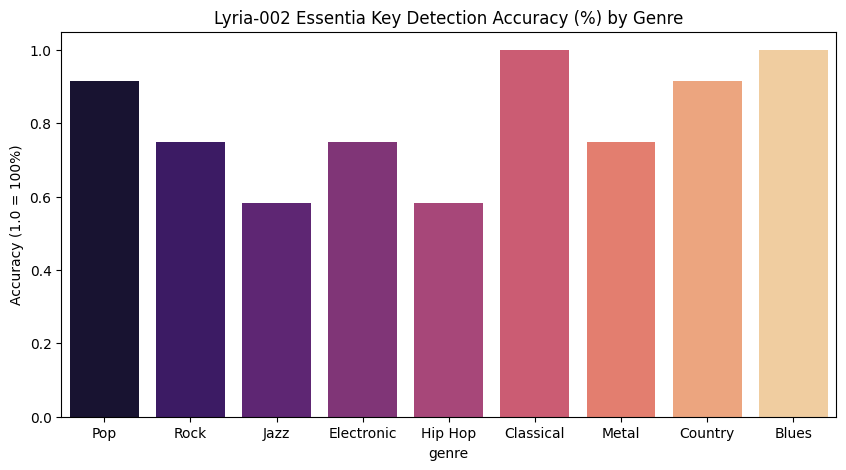

/tmp/ipykernel_170/1746489525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=key_df, x='genre', y='is_correct', palette='magma', errorbar=None)


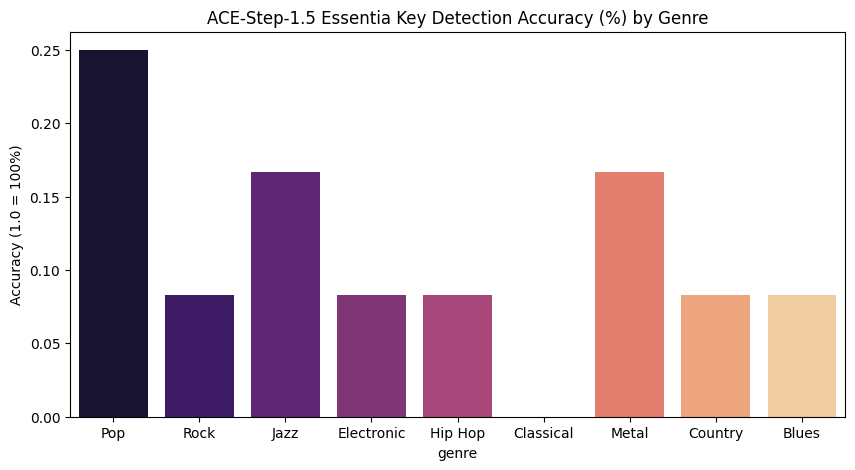

/tmp/ipykernel_170/1746489525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=key_df, x='genre', y='is_correct', palette='magma', errorbar=None)


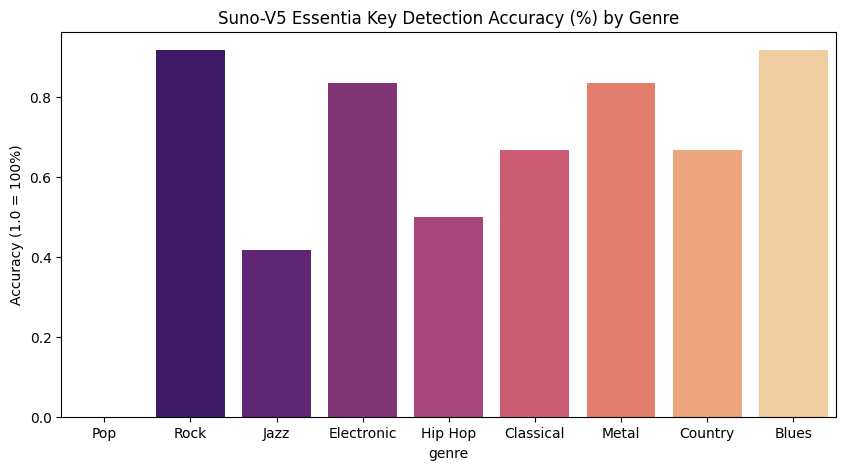

In [130]:
for model_name, model_data in audio_model_files.items():
    key_df = model_data['proccessed_tasks']['key'].copy()
    key_df['target_root'] = key_df['target'].str.split(' ').str[0]
    key_df['is_correct'] = (key_df['target_root'].str.strip() == key_df['_key'].str.strip()).astype(int)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=key_df, x='genre', y='is_correct', palette='magma', errorbar=None)

    plt.title(f'{model_name} Essentia Key Detection Accuracy (%) by Genre')
    plt.ylabel('Accuracy (1.0 = 100%)')
    # plt.axhline(0.5, color='red', linestyle='--', alpha=0.5) # Benchmark line
    plt.show()

# Mirex Key Scores

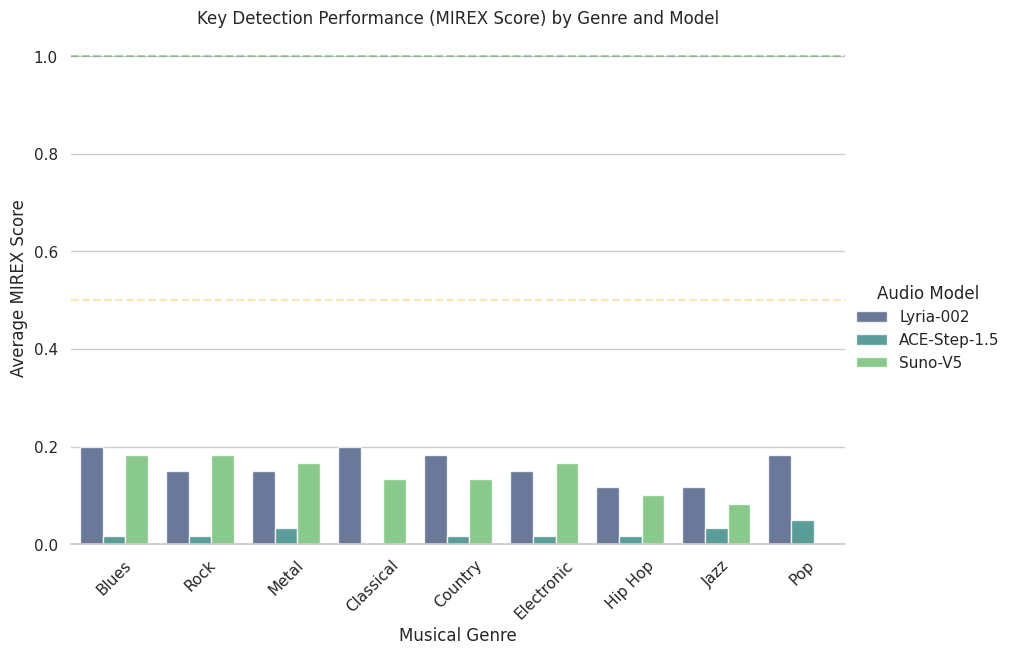

In [138]:
import os
import csv

for model_name, model_data in audio_model_files.items():
    key_df = model_data['proccessed_tasks']['key'].copy()

    key_df['target_root'] = key_df['target'].str.split(' ').str[0]
    key_df['target_score'] = key_df['mirex_score']

    plt.figure(figsize=(10, 5))
    sns.barplot(data=key_df, x='genre', y='is_correct', palette='magma', errorbar=None)

    plt.title(f'{model_name} Essentia Key Detection Accuracy (%) by Genre')
    plt.ylabel('Accuracy (1.0 = 100%)')
    # plt.axhline(0.5, color='red', linestyle='--', alpha=0.5) # Benchmark line
    plt.show()